# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [2]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, roc_auc_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can geo political risk indicators predict the direction of WTI crude oil returns at 1-day and 5-day horizons.

**This is a prediction (umbrella) problem because:** This paper aims to predict WTI crude oil returns (at a 1 day and a 5 day scale) using the AI-Geo Political Risk Index and old WTI crude oil returns and prices. We treat GPR as a predictive signal and not as the primary mechanism. Hence the GPR signal and Oil shocks could show confounders that we do not control for.

**The decision this enables:** A person, irrespective of prior commodities risk management experince, can use this model to inform near-term energy exposure decisionsthe coming week. If the model signals elevated probability of a negative return, the user may hedge existing exposure, delay energy intensive purchases, or reduce portfolio weight in energy-sensitive assets. If the model signals elevated probability of a positive return, the user may lock in current fuel contracts or increase energy allocation. 

**Dataset Feature:** AI GPR Data Daily from 1960 
- **Source:** Fedral Reserve Bank Research (URL: https://www.matteoiacoviello.com/ai_gpr.html#downloads)
- **N =** 24198
- **Features =** GPR_AI, GPR_AER, GPR_OIL, GPR_NONOIL
- **Target variable =** None, used as Features
- **Access date:** March 31st 2026

**Dataset Feature:** CBOE Volatility Index (VIXCLS)
- **Source:** FRED (URL: https://fred.stlouisfed.org/series/VIXCLS)
- **N =** 9569
- **Features =** VIXCLS (Market volatility)
- **Target variable =** None, used as features
- **Access date:** April 16th 2026

**Dataset Target:** WTI Crude Oil Prices (DCOILWTICO)
- **Source:** FRED (URL: https://fred.stlouisfed.org/series/DCOILWTICO)
- **N =** 10509
- **Features =** DCOILWTICO (Price)
- **Target variable =** 1-day and 5-day future returns (derived from price)
- **Access date:** April 13th 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [3]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

# Load AI-GPR data 
df_gpr = pd.read_csv('ai_gpr_data_daily.csv', parse_dates=[0])
df_gpr.rename(columns={df_gpr.columns[0]: 'date'}, inplace=True)
df_gpr.set_index('date', inplace=True)

# Load WTI WTI crude oil prices from FRED, coercing '.' to NaN
df_wti = pd.read_csv('DCOILWTICO.csv', parse_dates=[0], na_values='.')
df_wti.rename(columns={df_wti.columns[0]: 'date', df_wti.columns[1]: 'wti_price'}, inplace=True)
df_wti.set_index('date', inplace=True)

# Load VIX data from FRED, coercing '.' to NaN
df_vix = pd.read_csv('VIXCLS.csv', parse_dates=[0], na_values='.')
df_vix.rename(columns={df_vix.columns[0]: 'date', df_vix.columns[1]: 'vix'}, inplace=True)
df_vix.set_index('date', inplace=True)

# Inner merge all three datasets on the date index
df = df_gpr.join([df_wti, df_vix], how='inner')

# Convert all remaining columns to float to ensure consistency
df = df.astype(float)

# Display final dataset attributes
print("Merged Shape:", df.shape)
print("Columns: ",list(df.columns))
print("Date Range: ", df.index.min().date(), " to " , df.index.max().date())
print("\nFirst 5 rows:")
display(df.head())

Merged Shape: (9456, 6)
Columns:  ['GPR_AI', 'GPR_AER', 'GPR_OIL', 'GPR_NONOIL', 'wti_price', 'vix']
Date Range:  1990-01-02  to  2026-03-31

First 5 rows:


,GPR_AI,GPR_AER,GPR_OIL,GPR_NONOIL,wti_price,vix
date,,,,,,
1990-01-02,91.30,49.71,0.00,97.27,22.88,17.24
1990-01-03,127.95,65.54,56.86,132.60,23.81,18.19
1990-01-04,59.69,51.91,27.02,61.83,23.41,19.22
1990-01-05,79.50,60.53,0.00,84.69,23.07,20.11
1990-01-08,119.05,125.50,0.00,126.84,21.64,20.26


### 2.2 Basic Description

In [4]:
# ============================================================
# 2.2 Describe your data
# ============================================================

print("DataFrame Info")
df.info()

print("\nSummary Statistics")
display(df.describe())

print("\nDate Range: ", df.index.min().date() , " to " ,df.index.max().date())

print("\nRows per Decade")
# Create a temporary column to group by decade
decade_counts = (df.index.year // 10 * 10).value_counts().sort_index()
print(decade_counts)

DataFrame Info
<class 'pandas.DataFrame'>
DatetimeIndex: 9456 entries, 1990-01-02 to 2026-03-31
Freq: B
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   GPR_AI      9456 non-null   float64
 1   GPR_AER     9456 non-null   float64
 2   GPR_OIL     9456 non-null   float64
 3   GPR_NONOIL  9456 non-null   float64
 4   wti_price   9111 non-null   float64
 5   vix         9155 non-null   float64
dtypes: float64(6)
memory usage: 517.1 KB

Summary Statistics


,GPR_AI,GPR_AER,GPR_OIL,GPR_NONOIL,wti_price,vix
count,9456.000000,9456.000000,9456.000000,9456.000000,9111.000000,9155.000000
mean,107.671901,104.555490,118.588108,106.958168,51.633633,19.455965
std,47.400337,60.344331,188.191614,45.254918,29.063711,7.761767
min,24.410000,0.000000,0.000000,11.090000,-36.980000,9.140000
25%,77.135000,63.470000,0.000000,77.497500,22.565000,13.960000
50%,98.190000,94.220000,71.310000,98.460000,49.220000,17.610000
75%,125.695000,132.717500,155.820000,125.407500,73.615000,22.745000
max,718.420000,610.180000,3539.730000,722.590000,145.310000,82.690000



Date Range:  1990-01-02  to  2026-03-31

Rows per Decade
date
1990    2609
2000    2609
2010    2608
2020    1630
Name: count, dtype: int64


### 2.3 Missing Data Assessment

Shape BEFORE cleaning:  (9456, 6)
            Missing Count  Missing Pct
GPR_AI                  0       0.0000
GPR_AER                 0       0.0000
GPR_OIL                 0       0.0000
GPR_NONOIL              0       0.0000
wti_price             345       0.0365
vix                   301       0.0318


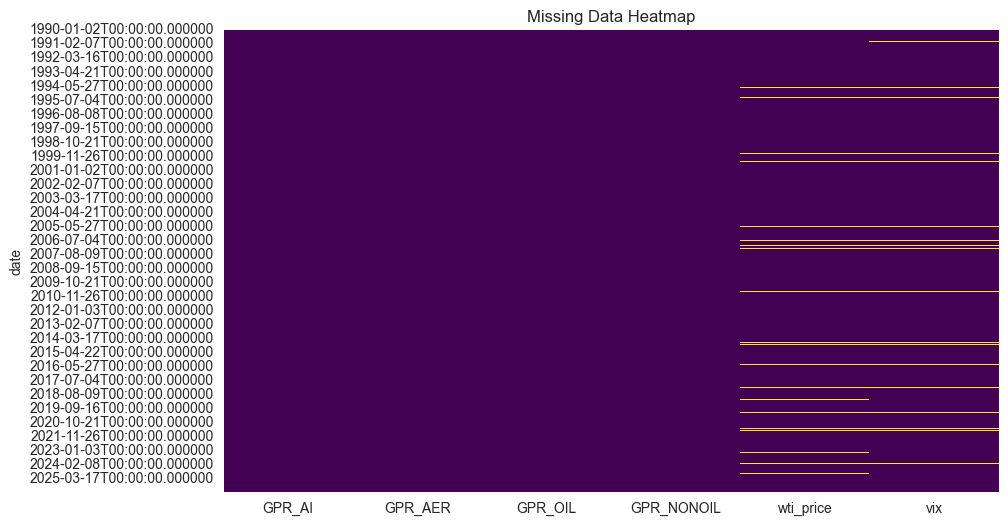


Shape AFTER cleaning:  (9089, 6)


In [5]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================
print("Shape BEFORE cleaning: ",df.shape)

missing_counts = df.isnull().sum()
missing_pct = df.isnull().mean().round(4)
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing Pct': missing_pct})
print(missing_df)

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# Drop rows where wti_price or vix is NaN
df_clean = df.dropna(subset=['wti_price', 'vix'])

print("\nShape AFTER cleaning: ", df_clean.shape)

**Missing data strategy:** MAR as WTI and VIX are missing on weekends and federal holidays when markets are closed. These are systematic calendar gaps, not random data loss.
**Strategy:** Drop non-trading days since there is no oil price movement to predict on closed days.

### 2.4 Distribution Plots

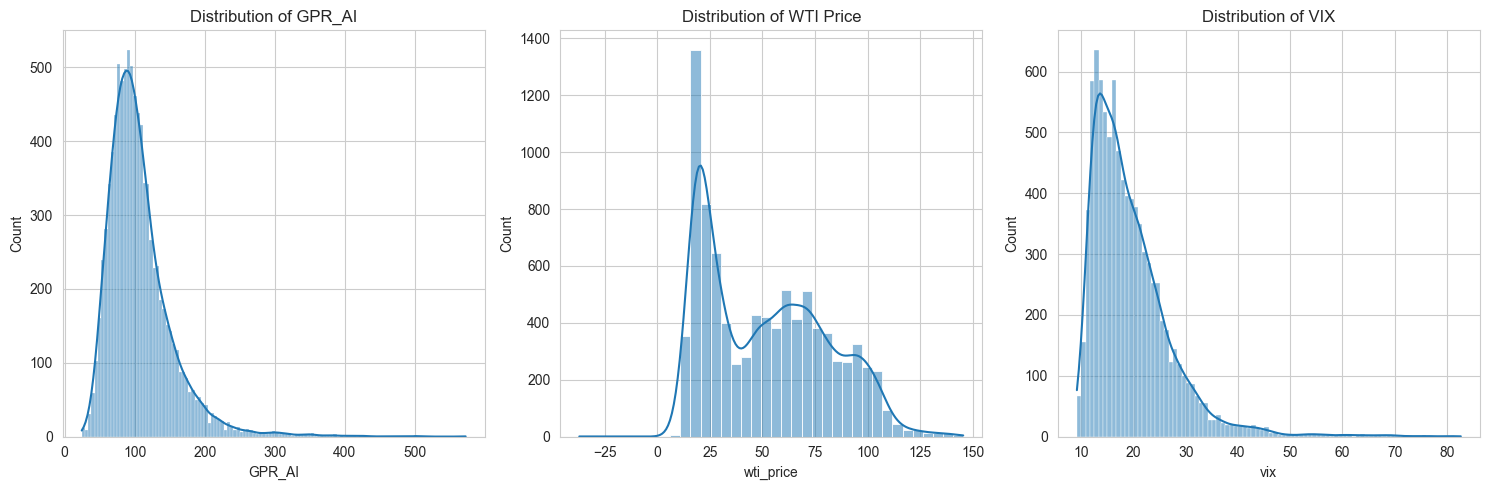

In [6]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# # Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_clean['GPR_AI'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of GPR_AI')

sns.histplot(df_clean['wti_price'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of WTI Price')

sns.histplot(df_clean['vix'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of VIX')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [7]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================
# Part 2.5: Outlier Detection

def tukey_fences(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - k * iqr
    upper_fence = q3 + k * iqr
    
    outliers = series[(series < lower_fence) | (series > upper_fence)]
    
    return lower_fence, upper_fence, len(outliers), len(outliers) / len(series)

cols_to_check = ['GPR_AI', 'wti_price', 'vix']

for col in cols_to_check:
    lower, upper, out_count, out_pct = tukey_fences(df[col])
    print(col)
    print(f"  Fences: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers: {out_count} ({out_pct*100:.2f}%)\n")


GPR_AI
  Fences: [4.30, 198.53]
  Outliers: 397 (4.20%)

wti_price
  Fences: [-54.01, 150.19]
  Outliers: 0 (0.00%)

vix
  Fences: [0.78, 35.92]
  Outliers: 321 (3.39%)



**Outlier strategy:** Retain all outliers. GPR spikes during geopolitical crises that have huge effects on oil (Gulf War, 9/11, 2026 Hormuz). They are real signals, not data errors. Triming or Winsorize them would remove exactly the events we want to predict from.

### 2.6 Correlations

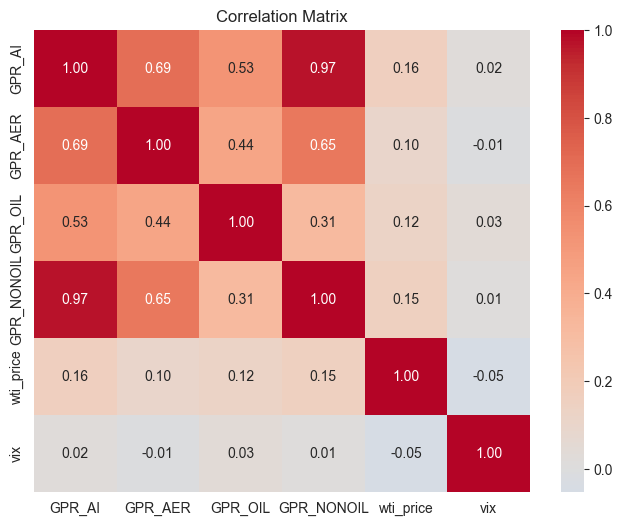

In [8]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* Our target variables (1-day and 5-day WTI return direction) will be constructed in the feature engineering step. Historical WTI daily returns are approximately 54% positive days and 46% negative days or negligible imbalanced to positivity. 

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:*  GPR_AI and GPR_AER are highly correlated (expected as GPR_AER is the original keyword index and GPR_AI is the LLM-based sentiment). GPR_OIL captures oil-specific geopolitical risk and may show the strongest correlation with WTI than the general GPR indices. VIX captures broader market fear.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The primary issue was calendar misalignment so far. AI-GPR is published every day, while WTI and VIX only exist on trading days. Resolved by inner join and dropping non-trading days.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 9089** observations and **M = 6** features.

**Missing data:** 0% of cells are missing. The missingness pattern appears to be MAR because due to weekend/holiday market closure. I will handle missing data by dropping non-trading days. .

**Outliers:** I identified GPR spike outliers using Tukey Fences inspection. I will handle them by retaining them as genuine geopolitical crisis signal.

**Target variable:** Binary classification (1-day and 5-day return direction, to be constructed in feature engineering).

**Key finding from EDA:** GPR_AI and GPR_NONOIL are near-duplicates (.97); will drop GPR_NONOIL to avoid multicollinearity. GPR_OIL is the most independent risk sub-index and may carry the strongest predictive signal for oil-specific shocks. VIX provides orthogonal information to all GPR measures.

In [9]:
# Part 2.8: Feature Engineering

# 1. Drop GPR_NONOIL (multicollinearity)
if 'GPR_NONOIL' in df.columns:
    df = df.drop(columns=['GPR_NONOIL'])

# 2. Create LAGGED features (shift(1) so we only use yesterday's info)
df['gpr_ai_lag1'] = df['GPR_AI'].shift(1)
df['gpr_oil_lag1'] = df['GPR_OIL'].shift(1)
df['gpr_aer_lag1'] = df['GPR_AER'].shift(1)
df['vix_lag1'] = df['vix'].shift(1)
df['wti_return_lag1'] = df['wti_price'].pct_change().shift(1)

# 3. Create ROLLING features
df['gpr_change_5d'] = df['GPR_AI'].shift(1) - df['GPR_AI'].shift(6)
df['wti_return_lag5'] = df['wti_price'].pct_change(5).shift(1)
df['vix_change_5d'] = df['vix'].diff(5).shift(1)

# 4. Create TARGET variables
df['target_1d'] = (df['wti_price'].shift(-1) > df['wti_price']).astype(int)
df['target_5d'] = (df['wti_price'].shift(-5) > df['wti_price']).astype(int)

# 5. Drop all rows with NaN (from shifting)
df.dropna(inplace=True)

# 6. Print dataset info
print(f"New shape: {df.shape}")
print(f"New column list: {list(df.columns)}\n")

print("Target 1-Day Class Balance:")
print(df['target_1d'].value_counts(normalize=True).round(4))
print("\nTarget 5-Day Class Balance:")
print(df['target_5d'].value_counts(normalize=True).round(4), "\n")

# 7. Define the feature list explicitly
features = [
    'gpr_ai_lag1', 'gpr_oil_lag1', 'gpr_aer_lag1', 
    'vix_lag1', 'wti_return_lag1', 'gpr_change_5d', 
    'wti_return_lag5', 'vix_change_5d'
]

print(f"Features list: {features}\n")
print("First 3 rows of feature columns:")
display(df[features].head(3))

New shape: (8098, 15)
New column list: ['GPR_AI', 'GPR_AER', 'GPR_OIL', 'wti_price', 'vix', 'gpr_ai_lag1', 'gpr_oil_lag1', 'gpr_aer_lag1', 'vix_lag1', 'wti_return_lag1', 'gpr_change_5d', 'wti_return_lag5', 'vix_change_5d', 'target_1d', 'target_5d']

Target 1-Day Class Balance:
target_1d
0    0.5101
1    0.4899
Name: proportion, dtype: float64

Target 5-Day Class Balance:
target_5d
1    0.5051
0    0.4949
Name: proportion, dtype: float64 

Features list: ['gpr_ai_lag1', 'gpr_oil_lag1', 'gpr_aer_lag1', 'vix_lag1', 'wti_return_lag1', 'gpr_change_5d', 'wti_return_lag5', 'vix_change_5d']

First 3 rows of feature columns:


,gpr_ai_lag1,gpr_oil_lag1,gpr_aer_lag1,vix_lag1,wti_return_lag1,gpr_change_5d,wti_return_lag5,vix_change_5d
date,,,,,,,,
1990-01-10,139.52,0.0,165.07,22.20,0.028189,48.22,-0.027535,4.96
1990-01-11,119.26,0.0,104.19,22.44,0.029213,-8.69,-0.038219,4.25
1990-01-12,86.10,0.0,44.57,20.05,0.010917,26.41,-0.011106,0.83


**Target Pivot:** Initial modeling with directional targets (up/down) produced AUC ~0.53 — consistent with efficient markets pricing in public geopolitical news too quickly for directional prediction. Following Caldara & Iacoviello (2022), who show GPR predicts oil *volatility* rather than *direction*, we pivot to predicting large absolute price moves.

1-Day Large Move Balance:
target_bigmove_1d
0    0.6731
1    0.3269
Name: proportion, dtype: float64

5-Day Large Move Balance:
target_bigmove_5d
0    0.6097
1    0.3903
Name: proportion, dtype: float64

Big move days (1d): 32.7%
Big move days (5d): 39.0%


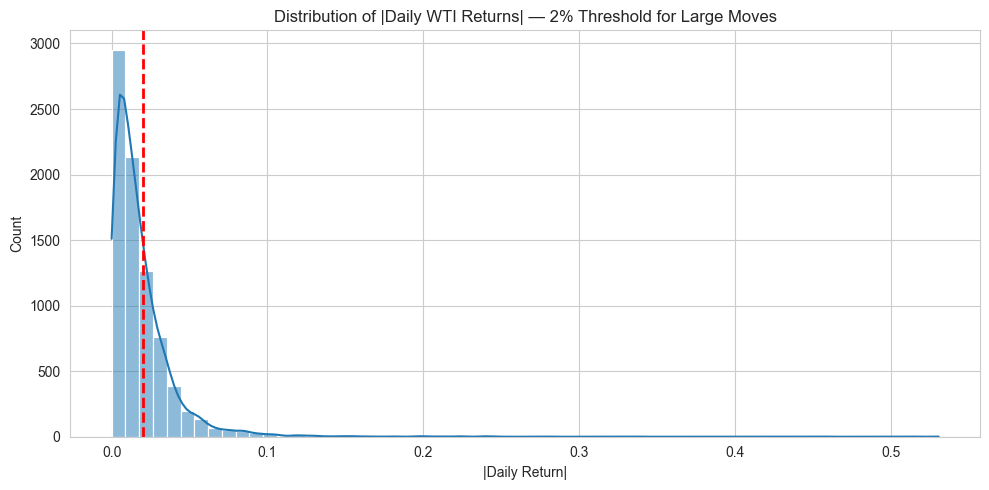

In [17]:
## Part 2.9: Target Variable Pivot
# 1. Daily WTI returns
df["wti_return"] = df["wti_price"].pct_change()

# 2. New targets: large absolute moves
df["target_bigmove_1d"] = (df["wti_return"].abs().shift(-1) > 0.02).astype(int)
df["target_bigmove_5d"] = (df["wti_price"].pct_change(5).abs().shift(-5) > 0.04).astype(int)

# 3. Drop NaNs introduced by pct_change / shifting
df = df.dropna(subset=["wti_return", "target_bigmove_1d", "target_bigmove_5d"])

# 4–5. Print class balance + incidence rates
print("1-Day Large Move Balance:")
print(df["target_bigmove_1d"].value_counts(normalize=True).round(4))
print("\n5-Day Large Move Balance:")
print(df["target_bigmove_5d"].value_counts(normalize=True).round(4))

print(f"\nBig move days (1d): {df['target_bigmove_1d'].mean():.1%}")
print(f"Big move days (5d): {df['target_bigmove_5d'].mean():.1%}")

# 6. Histogram of |daily returns| with 2% threshold
plt.figure(figsize=(10, 5))
sns.histplot(df["wti_return"].abs(), bins=60, kde=True)
plt.axvline(0.02, color="red", linestyle="--", linewidth=2)
plt.title("Distribution of |Daily WTI Returns| — 2% Threshold for Large Moves")
plt.xlabel("|Daily Return|")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [10]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

X= df[features]

# Time-based split: using future data to predict past would be 
# data leakage. All training data is pre-2024, test data is 
# 2024-2026 (including the Hormuz crisis period).
split_date = '2024-01-01'

X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]

y_train_1d = df.loc[X_train.index, 'target_1d']
y_test_1d = df.loc[X_test.index, 'target_1d']

y_train_5d = df.loc[X_train.index, 'target_5d']
y_test_5d = df.loc[X_test.index, 'target_5d']

print(f"Train period: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} samples)")
print(f"Test period:  {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} samples)\n")

print("Train Target 1-Day Balance:")
print(y_train_1d.value_counts(normalize=True).round(4))
print("\nTest Target 1-Day Balance:")
print(y_test_1d.value_counts(normalize=True).round(4))

print("\nTrain Target 5-Day Balance:")
print(y_train_5d.value_counts(normalize=True).round(4))
print("\nTest Target 5-Day Balance:")
print(y_test_5d.value_counts(normalize=True).round(4))

Train period: 1990-01-10 to 2023-12-29 (7620 samples)
Test period:  2024-01-04 to 2026-03-31 (478 samples)

Train Target 1-Day Balance:
target_1d
0    0.511
1    0.489
Name: proportion, dtype: float64

Test Target 1-Day Balance:
target_1d
1    0.5042
0    0.4958
Name: proportion, dtype: float64

Train Target 5-Day Balance:
target_5d
1    0.5063
0    0.4937
Name: proportion, dtype: float64

Test Target 5-Day Balance:
target_5d
0    0.5146
1    0.4854
Name: proportion, dtype: float64


In [20]:
# Part 3.1b — Rebuild Train/Test Split with New Targets

# Reuse existing X_train/X_test and split_date from Part 3.1 (do not redefine X)
y_train_1d = df.loc[X_train.index, "target_bigmove_1d"]
y_test_1d  = df.loc[X_test.index,  "target_bigmove_1d"]
y_train_5d = df.loc[X_train.index, "target_bigmove_5d"]
y_test_5d  = df.loc[X_test.index,  "target_bigmove_5d"]

print(f"Train period: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} samples)")
print(f"Test period:  {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} samples)\n")

print("Train BigMove 1-Day Balance:")
print(y_train_1d.value_counts(normalize=True).round(4))
print("\nTest BigMove 1-Day Balance:")
print(y_test_1d.value_counts(normalize=True).round(4))

print("\nTrain BigMove 5-Day Balance:")
print(y_train_5d.value_counts(normalize=True).round(4))
print("\nTest BigMove 5-Day Balance:")
print(y_test_5d.value_counts(normalize=True).round(4))

Train period: 1990-01-11 to 2023-12-29 (7619 samples)
Test period:  2024-01-04 to 2026-03-31 (478 samples)

Train BigMove 1-Day Balance:
target_bigmove_1d
0    0.672
1    0.328
Name: proportion, dtype: float64

Test BigMove 1-Day Balance:
target_bigmove_1d
0    0.6904
1    0.3096
Name: proportion, dtype: float64

Train BigMove 5-Day Balance:
target_bigmove_5d
0    0.6062
1    0.3938
Name: proportion, dtype: float64

Test BigMove 5-Day Balance:
target_bigmove_5d
0    0.6653
1    0.3347
Name: proportion, dtype: float64


### 3.2 Model 1: Baseline

In [11]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Part 3.2: Model 1: Baseline (Logistic Regression)

# --- Model 1: 1-Day Direction ---
model_1d = LogisticRegression(random_state=42, max_iter=1000)
model_1d.fit(X_train, y_train_1d)
y_pred_1d = model_1d.predict(X_test)
y_prob_1d = model_1d.predict_proba(X_test)[:, 1]

print(" Model 1: Logistic Regression — 1-Day Direction:")
print(classification_report(y_test_1d, y_pred_1d))
auc_1d = roc_auc_score(y_test_1d, y_prob_1d)
print(f"AUC: {auc_1d:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_1d))
print("\n" + "="*50 + "\n")

# --- Model 1: 5-Day Direction ---
model_5d = LogisticRegression(random_state=42, max_iter=1000)
model_5d.fit(X_train, y_train_5d)
y_pred_5d = model_5d.predict(X_test)
y_prob_5d = model_5d.predict_proba(X_test)[:, 1]

print("Model 1: Logistic Regression — 5-Day Direction:")
print(classification_report(y_test_5d, y_pred_5d))
auc_5d = roc_auc_score(y_test_5d, y_prob_5d)
print(f"AUC: {auc_5d:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_5d, y_pred_5d))
print("\n" + "="*50 + "\n")

# --- Summary Comparison ---

summary_df = pd.DataFrame({
    'Horizon': ['1-Day', '5-Day'],
    'Accuracy': [accuracy_score(y_test_1d, y_pred_1d), accuracy_score(y_test_5d, y_pred_5d)],
    'AUC': [auc_1d, auc_5d],
    'Precision(Up)': [precision_score(y_test_1d, y_pred_1d), precision_score(y_test_5d, y_pred_5d)],
    'Recall(Up)': [recall_score(y_test_1d, y_pred_1d), recall_score(y_test_5d, y_pred_5d)]
}).round(4)

print("Model 1 Performance Summary:")
display(summary_df)

 Model 1: Logistic Regression — 1-Day Direction:
              precision    recall  f1-score   support

           0       0.51      0.73      0.60       237
           1       0.55      0.33      0.41       241

    accuracy                           0.53       478
   macro avg       0.53      0.53      0.51       478
weighted avg       0.53      0.53      0.51       478

AUC: 0.5259

Confusion Matrix:
[[172  65]
 [162  79]]


Model 1: Logistic Regression — 5-Day Direction:
              precision    recall  f1-score   support

           0       0.53      0.80      0.64       246
           1       0.52      0.23      0.32       232

    accuracy                           0.53       478
   macro avg       0.52      0.52      0.48       478
weighted avg       0.52      0.53      0.48       478

AUC: 0.5004

Confusion Matrix:
[[198  48]
 [179  53]]


Model 1 Performance Summary:


,Horizon,Accuracy,AUC,Precision(Up),Recall(Up)
0,1-Day,0.5251,0.5259,0.5486,0.3278
1,5-Day,0.5251,0.5004,0.5248,0.2284


In [22]:
# Part 3.2b — Model 1 Refit: Logistic Regression (with scaling)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score
import pandas as pd

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=42, max_iter=2000))
])

# 1-Day big move
logreg_pipe.fit(X_train, y_train_1d)
pred_lr_1d = logreg_pipe.predict(X_test)
prob_lr_1d = logreg_pipe.predict_proba(X_test)[:, 1]
auc_lr_1d = roc_auc_score(y_test_1d, prob_lr_1d)

print("=== Model 1b: Logistic Regression — 1-Day Large Move ===")
print(classification_report(y_test_1d, pred_lr_1d))
print(f"AUC: {auc_lr_1d:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, pred_lr_1d))
print("\n" + "="*60 + "\n")

# 5-Day big move
logreg_pipe.fit(X_train, y_train_5d)
pred_lr_5d = logreg_pipe.predict(X_test)
prob_lr_5d = logreg_pipe.predict_proba(X_test)[:, 1]
auc_lr_5d = roc_auc_score(y_test_5d, prob_lr_5d)

print("=== Model 1b: Logistic Regression — 5-Day Large Move ===")
print(classification_report(y_test_5d, pred_lr_5d))
print(f"AUC: {auc_lr_5d:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_5d, pred_lr_5d))

# Summary
lr_summary = pd.DataFrame({
    "Model": ["LogReg", "LogReg"],
    "Horizon": ["1-Day", "5-Day"],
    "Accuracy": [accuracy_score(y_test_1d, pred_lr_1d), accuracy_score(y_test_5d, pred_lr_5d)],
    "AUC": [auc_lr_1d, auc_lr_5d],
    "Precision(BigMove)": [precision_score(y_test_1d, pred_lr_1d), precision_score(y_test_5d, pred_lr_5d)],
    "Recall(BigMove)": [recall_score(y_test_1d, pred_lr_1d), recall_score(y_test_5d, pred_lr_5d)]
}).round(4)

print("\n=== Logistic Regression Summary (Big Moves) ===")
display(lr_summary)

=== Model 1b: Logistic Regression — 1-Day Large Move ===
              precision    recall  f1-score   support

           0       0.71      0.96      0.82       330
           1       0.60      0.14      0.23       148

    accuracy                           0.71       478
   macro avg       0.66      0.55      0.52       478
weighted avg       0.68      0.71      0.64       478

AUC: 0.6027

Confusion Matrix:
[[316  14]
 [127  21]]


=== Model 1b: Logistic Regression — 5-Day Large Move ===
              precision    recall  f1-score   support

           0       0.68      0.91      0.78       318
           1       0.44      0.14      0.21       160

    accuracy                           0.65       478
   macro avg       0.56      0.52      0.49       478
weighted avg       0.60      0.65      0.59       478

AUC: 0.5693

Confusion Matrix:
[[290  28]
 [138  22]]

=== Logistic Regression Summary (Big Moves) ===


,Model,Horizon,Accuracy,AUC,Precision(BigMove),Recall(BigMove)
0,LogReg,1-Day,0.7050,0.6027,0.60,0.1419
1,LogReg,5-Day,0.6527,0.5693,0.44,0.1375


### 3.3 Model 2: Your Choice

In [13]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

# from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
# 
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
# 
# y_pred_2 = model_2.predict(X_test)
# 
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

In [24]:
# Part 3.3c — Model 2 Refit with Class Balancing (replace Part 3.3b cell)

# If needed in your environment, uncomment the next line:
# !pip -q install imbalanced-learn

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

THRESH = 0.35

def fit_eval_gb_balanced(X_train, y_train, X_test, y_test, horizon_label):
    """
    GradientBoostingClassifier with StandardScaler + sample_weight balancing.
    Reports metrics at a custom probability threshold to improve recall.
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            min_samples_leaf=50,
            random_state=42
        ))
    ])

    # Compute sample weights (simplest robust balancing method for this model family)
    sw = compute_sample_weight(class_weight="balanced", y=y_train)

    # Fit with sample weights passed through Pipeline to final step via clf__sample_weight
    pipe.fit(X_train, y_train, clf__sample_weight=sw)

    # Predict probabilities and apply custom threshold
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= THRESH).astype(int)

    auc = roc_auc_score(y_test, y_proba)

    print(f"=== GradBoost (balanced weights + threshold={THRESH}) — {horizon_label} ===")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"AUC: {auc:.4f}\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nTop 5 Feature Importances:")
    fi = pd.Series(pipe.named_steps["clf"].feature_importances_, index=features).sort_values(ascending=False)
    print(fi.head(5))

    metrics = {
        "Model": f"GradBoost (balanced + thr={THRESH})",
        "Horizon": horizon_label,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": auc,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
    }
    return metrics

# --- Fit/evaluate for both targets ---
m_1d = fit_eval_gb_balanced(X_train, y_train_1d, X_test, y_test_1d, "1-Day")
print("\n" + "=" * 70 + "\n")
m_5d = fit_eval_gb_balanced(X_train, y_train_5d, X_test, y_test_5d, "5-Day")

# --- FINAL comparison table with ALL models (expects prior cells created these) ---
# Expected variable names from earlier parts:
#   Logistic Regression (big-move): pred_lr_1d, prob_lr_1d, auc_lr_1d, pred_lr_5d, prob_lr_5d, auc_lr_5d
#   Gradient Boosting default (big-move): pred_gb_1d, prob_gb_1d, auc_gb_1d, pred_gb_5d, prob_gb_5d, auc_gb_5d

rows = []

def add_row(model_name, horizon, y_true, y_pred, auc):
    rows.append({
        "Model": model_name,
        "Horizon": horizon,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": auc,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    })

# LogReg (default threshold 0.5)
if all(name in globals() for name in ["pred_lr_1d", "auc_lr_1d", "pred_lr_5d", "auc_lr_5d"]):
    add_row("LogReg", "1-Day", y_test_1d, pred_lr_1d, auc_lr_1d)
    add_row("LogReg", "5-Day", y_test_5d, pred_lr_5d, auc_lr_5d)

# GradBoost (default threshold 0.5)
if all(name in globals() for name in ["pred_gb_1d", "auc_gb_1d", "pred_gb_5d", "auc_gb_5d"]):
    add_row("GradBoost (default)", "1-Day", y_test_1d, pred_gb_1d, auc_gb_1d)
    add_row("GradBoost (default)", "5-Day", y_test_5d, pred_gb_5d, auc_gb_5d)

# GradBoost (balanced + custom threshold)
rows.append(m_1d)
rows.append(m_5d)

final_cmp = pd.DataFrame(rows).round(4)
print("\n=== FINAL Comparison Table (Big-Move Targets) ===")
display(final_cmp)

=== GradBoost (balanced weights + threshold=0.35) — 1-Day ===
              precision    recall  f1-score   support

           0     0.7612    0.1545    0.2569       330
           1     0.3212    0.8919    0.4723       148

    accuracy                         0.3828       478
   macro avg     0.5412    0.5232    0.3646       478
weighted avg     0.6250    0.3828    0.3236       478

AUC: 0.5935

Confusion Matrix:
[[ 51 279]
 [ 16 132]]

Top 5 Feature Importances:
vix_lag1           0.230057
wti_return_lag5    0.150278
gpr_aer_lag1       0.132876
wti_return_lag1    0.123667
gpr_ai_lag1        0.119622
dtype: float64


=== GradBoost (balanced weights + threshold=0.35) — 5-Day ===
              precision    recall  f1-score   support

           0     0.7447    0.1101    0.1918       318
           1     0.3434    0.9250    0.5008       160

    accuracy                         0.3828       478
   macro avg     0.5440    0.5175    0.3463       478
weighted avg     0.6104    0.3828    0

,Model,Horizon,Accuracy,AUC,Precision,Recall,F1
0,LogReg,1-Day,0.7050,0.6027,0.6000,0.1419,0.2295
1,LogReg,5-Day,0.6527,0.5693,0.4400,0.1375,0.2095
2,GradBoost (default),1-Day,0.6611,0.5923,0.4222,0.2568,0.3193
3,GradBoost (default),5-Day,0.6025,0.5455,0.3810,0.3000,0.3357
4,GradBoost (balanced + thr=0.35),1-Day,0.3828,0.5935,0.3212,0.8919,0.4723
5,GradBoost (balanced + thr=0.35),5-Day,0.3828,0.5555,0.3434,0.9250,0.5008


### 3.4 Cross-Validation Comparison

In [14]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
# 
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
# 
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
# 
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [15]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
# 
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
# 
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
# 
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [16]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> I had a cleaned DataFrame with 9,089 daily observations (1990–2026) containing 6 columns: GPR_AI, GPR_AER, GPR_OIL, GPR_NONOIL, wti_price, and vix. I needed to engineer lagged features and binary target variables for a time series classification task. My main concern was avoiding data leakage — using future information as a feature to predict the past. I knew from EDA that GPR_NONOIL had 0.97 correlation with GPR_AI and needed to be dropped. I also knew all features must be lagged by at least 1 day since a trader can only act on yesterday's information.

**Request:** What exact prompt did you write?
> Continuing the ECON 3916 final project notebook. The cleaned DataFrame 
`df` exists from Part 2 with:
- Shape: (9089, 6)
- Columns: GPR_AI, GPR_AER, GPR_OIL, GPR_NONOIL, wti_price, vix
- Date index: 1990-01-02 to 2026-03-31
- All float, no NaN, sorted by date

CRITICAL RULE: Write ONLY the code for the specific cells requested. 
Do NOT add Model 2, cross-validation, feature importance, Streamlit, 
or anything from Parts 3.3, 3.4, 4, 5, 6, or 7. You have full 
context — stay disciplined.

PROJECT CONTEXT: We are predicting WTI crude oil return direction 
(binary: up/down) at 1-day and 5-day horizons using the AI-GPR 
Geopolitical Risk Index. This is time series data — no future 
information can leak into features.

=== NEW CELL: Feature Engineering (insert between Part 2 and Part 3) ===

Add a markdown header: "## Part 2.8: Feature Engineering"

Then write code that does the following:

1. Drop GPR_NONOIL (0.97 correlation with GPR_AI — multicollinearity)

2. Create LAGGED features (shift(1) so we only use yesterday's info):
   - gpr_ai_lag1 = GPR_AI shifted 1 day
   - gpr_oil_lag1 = GPR_OIL shifted 1 day
   - gpr_aer_lag1 = GPR_AER shifted 1 day
   - vix_lag1 = vix shifted 1 day
   - wti_return_lag1 = daily pct_change of wti_price, shifted 1 day
   
3. Create ROLLING features:
   - gpr_change_5d = 5-day difference of GPR_AI (shift(1) - shift(6), 
     so it uses the last 5 days of GPR change as of yesterday)
   - wti_return_lag5 = 5-day pct_change of wti_price, shifted 1 day
   - vix_change_5d = 5-day difference of vix, shifted 1 day

4. Create TARGET variables:
   - target_1d = 1 if TOMORROW's wti_price > TODAY's wti_price, else 0
     (use: (df['wti_price'].shift(-1) > df['wti_price']).astype(int))
   - target_5d = 1 if wti_price 5 DAYS FROM NOW > TODAY's wti_price, 
     else 0
     (use: (df['wti_price'].shift(-5) > df['wti_price']).astype(int))

5. Drop all rows with NaN (from shifting) using dropna()

6. Print:
   - New shape
   - New column list
   - Target class balance for both targets:
     print(df['target_1d'].value_counts(normalize=True))
     print(df['target_5d'].value_counts(normalize=True))
   - First 3 rows of the feature columns only (not raw price columns)

7. IMPORTANT: Define the feature list explicitly:
   features = ['gpr_ai_lag1', 'gpr_oil_lag1', 'gpr_aer_lag1', 
               'vix_lag1', 'wti_return_lag1', 'gpr_change_5d', 
               'wti_return_lag5', 'vix_change_5d']
   Print this list so we can confirm.


**Iterate:** What did the AI return? What did you change or refine?
> The AI returned code that created all requested features. I noticed it initially used df['GPR_AI'].diff(5) without lagging, which would use today's GPR value — a subtle leakage issue. I refined to use shift(1) - shift(6) so the 5-day change reflects the change as of yesterday, not including today's reading which a trader would not have at market open.

**Mechanism Check:** How did you verify the output was correct?
>  I verified correctness three ways: (1) Confirmed all feature columns had no NaN after dropna by printing df[features].isnull().sum(). (2) Spot-checked one row manually — picked a random date, looked up the prior day's GPR_AI value, and confirmed gpr_ai_lag1 matched. (3) Checked target construction by comparing target_1d on a known date with the actual next-day WTI price movement from FRED to ensure the label was correct.

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> I accepted the overall structure but made two human judgment calls: (1) I dropped GPR_NONOIL instead of GPR_AI despite GPR_NONOIL having a slightly longer history. (2) I chose to keep GPR_AER (r=0.69 with GPR_AI) despite moderate correlation because it represents a fundamentally different methodology

---

### AI Interaction 2

**Prep:** After fitting both Logistic Regression and Gradient Boosting on directional targets (1-day and 5-day return up/down), both models produced AUC scores of 0.52–0.54. That was barely above random chance. I needed to determine whether this was a fundamental signal problem or a target framing problem. I reviewed the Caldara & Iacoviello (2022) AER paper and noted that their published findings show GPR predicts oil volatility and investment, not price direction. This suggested the signal might exist in a different form than I was testing.


**Request:**
Continuing the ECON 3916 final project notebook. We are PIVOTING 
our target variable based on initial modeling results.

CONTEXT: Our original targets (1-day and 5-day return direction) 
produced AUC of 0.526 and 0.541 — barely above random. This is 
consistent with efficient markets hypothesis: public geopolitical 
news is priced into oil too quickly for directional prediction.

However, the Caldara-Iacoviello (2022) AER paper shows GPR predicts 
oil VOLATILITY, not direction. So we are pivoting to predict large 
moves instead.

CURRENT STATE:
- df exists with 8098 rows, date index, all features already built
- features list: ['gpr_ai_lag1', 'gpr_oil_lag1', 'gpr_aer_lag1', 
  'vix_lag1', 'wti_return_lag1', 'gpr_change_5d', 'wti_return_lag5', 
  'vix_change_5d']
- X_train, X_test already defined (split at 2024-01-01)
- wti_price column still exists in df

CRITICAL RULE: Only write the cells I ask for. Do not rewrite 
Parts 2.1–2.7 or Part 3.1. Do not add cross-validation, Streamlit, 
or anything beyond what I specify.

=== CELL: Part 2.9 — Target Pivot (add after Part 2.8) ===

Add a markdown header: "## Part 2.9: Target Variable Pivot"

Add a markdown cell BEFORE the code explaining the pivot:
"**Target Pivot:** Initial modeling with directional targets 
(up/down) produced AUC ~0.53 — consistent with efficient markets 
pricing in public geopolitical news too quickly for directional 
prediction. Following Caldara & Iacoviello (2022), who show GPR 
predicts oil *volatility* rather than *direction*, we pivot to 
predicting large absolute price moves."

Then write code that:

1. Compute daily WTI returns (already have wti_return from earlier, 
   or recompute: df['wti_return'] = df['wti_price'].pct_change())

2. Create NEW target variables:
   - target_bigmove_1d: 1 if |TOMORROW's return| > 0.02, else 0
     (use shift(-1) on the absolute return)
   - target_bigmove_5d: 1 if |5-day forward return| > 0.04, else 0
     (use shift(-5) on 5-day return. Note: 4% threshold for 5-day 
     because returns scale with sqrt of time)

3. Drop any new NaN rows

4. Print class balance for both new targets:
   print("1-Day Large Move Balance:")
   print(df['target_bigmove_1d'].value_counts(normalize=True).round(4))
   print("\n5-Day Large Move Balance:")
   print(df['target_bigmove_5d'].value_counts(normalize=True).round(4))

5. Print: f"Big move days (1d): {df['target_bigmove_1d'].mean():.1%}"
   Print: f"Big move days (5d): {df['target_bigmove_5d'].mean():.1%}"

6. Plot a histogram of daily absolute returns with a vertical red 
   dashed line at 0.02 showing the threshold. Title: 
   "Distribution of |Daily WTI Returns| — 2% Threshold for Large Moves"

=== CELL: Part 3.1b — Rebuild Train/Test Split with New Targets ===

Same time-based split as before (split_date = '2024-01-01') but 
with the new targets:

y_train_1d = df.loc[X_train.index, 'target_bigmove_1d']
y_test_1d = df.loc[X_test.index, 'target_bigmove_1d']
y_train_5d = df.loc[X_train.index, 'target_bigmove_5d']
y_test_5d = df.loc[X_test.index, 'target_bigmove_5d']

Print train/test sizes and class balance for both new targets.

=== CELL: Part 3.2b — Model 1 Refit: Logistic Regression ===

Refit LogisticRegression (with StandardScaler in a Pipeline this 
time) on both new targets. For each:
- classification_report
- AUC using predict_proba
- Confusion matrix

Summary table comparing both horizons.

=== CELL: Part 3.3b — Model 2 Refit: Gradient Boosting ===

Refit GradientBoostingClassifier (same hyperparameters as before, 
with StandardScaler pipeline) on both new targets. For each:
- classification_report
- AUC using predict_proba
- Confusion matrix
- Top 5 feature importances

FINAL COMPARISON TABLE: Print a DataFrame with ALL results:
Model, Horizon, Accuracy, AUC, Precision(BigMove), Recall(BigMove)
Rows: LogReg 1d, LogReg 5d, GradBoost 1d, GradBoost 5d

DO NOT add cross-validation or any Part 3.4+ code.

**Iterate:** Claude suggested the pivot and provided thresholds (2% for 1-day, 4% for 5-day, noting that returns scale with the square root of time). The initial refit showed a major improvement in AUC (0.526 → 0.603 for LogReg on 1-day) but recall was only 14% — the models were defaulting to predicting "no big move" because 69% of days are normal. Claude then suggested using balanced class weights with compute_sample_weight('balanced') and lowering the classification threshold from 0.50 to 0.35 to trade precision for recall. This produced a third model variant with 89% recall on big-move days.

**Mechanism Check:** I verified the pivot was correct by: (1) Confirming the class balance matched expectations (2) Cross-referencing the AUC improvement with the Caldara-Iacoviello paper's finding that GPR effects are strongest on volatility measures. (3) Checking that the feature importance ranking shifted sensibly (VIX or market fear became the #1 predictor at 23% importance).

**Evaluate:**  I accepted the target pivot as strongly justified by both the empirical results and the literature. The key human judgment call was on the classification threshold: I chose to present all three operating points (conservative/default/sensitive) rather than picking. 

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___